# 00 — เตรียมข้อมูล AOD (MAIAC) และ PM2.5 (PCD) สำหรับชุดบทเรียน AOD–PM2.5

**สำหรับผู้สอน** · รันครั้งเดียว แล้วนำโฟลเดอร์ `data/` ขึ้น [Teach_AOD_PM_PCD](https://github.com/nattaponm/Teach_AOD_PM_PCD) ให้นิสิตใช้ใน Notebook 01–05

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nattaponm/Teach_AOD_PM_PCD/blob/main/00_Data_Preparation_AOD_PM25.ipynb)

---

## ทำไมต้องมีไฟล์นี้

นิสิตควรใช้เวลากับ **การทำความเข้าใจความสัมพันธ์ AOD–PM2.5** ไม่ใช่กับการรอดาวน์โหลดหรือแก้ปัญหาบัญชี Earth Engine
ไฟล์นี้จึงทำงานหนักทั้งหมดไว้ล่วงหน้า แล้วส่งต่อเป็นไฟล์ขนาดเล็กที่อ่านได้ทันที

```
PCD Excel (GitHub)  ──►  A. ทำความสะอาด PM2.5      ──►  pm25_long.csv
Air4Thai + จังหวัด   ──►  B. พิกัดสถานี + ขอบเขต    ──►  stations.geojson, provinces.geojson
MCD19A2 (GEE)       ──►  C. ดึง AOD ที่สถานีรายวัน   ──►  aod_pm_matchup.csv
MCD19A2 (GEE)       ──►  D. ภาพ AOD เฉลี่ยรายเดือน  ──►  aod_YYYY_MM.tif
```

## ช่วงเวลาที่ใช้: กุมภาพันธ์–เมษายน 2023

เลือกปี **2023** เพราะเป็นปีที่ฝุ่นรุนแรงที่สุดในชุดข้อมูล 2021–2025
(ค่าเฉลี่ยทุกสถานีช่วง ก.พ.–เม.ย. ประมาณ 48 µg/m³ เทียบกับ 28–38 µg/m³ ในปีอื่น)
และเลือก ก.พ.–เม.ย. เพราะเป็นช่วงฝุ่นสูงและเมฆน้อย ดาวเทียมจึงวัด AOD ได้บ่อย

> 📌 **หมายเหตุผู้สอน** — ต้องการเปลี่ยนปี แก้ `YEAR` ใน cell ตั้งค่าเพียงจุดเดียว ทุกส่วนจะเปลี่ยนตาม

## 0. ตั้งค่า

ติดตั้ง library ที่ Colab ยังไม่มี แล้วกำหนดค่าหลักของงานไว้ที่เดียว

In [1]:
!pip -q install rasterio

In [2]:
from pathlib import Path
import io
import time

import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import matplotlib.pyplot as plt

# ---------- ค่าหลักของงาน (แก้ที่นี่ที่เดียว) ----------
YEAR = 2023                 # ปีที่ฝุ่นรุนแรงที่สุดในชุดข้อมูล
MONTHS = [2, 3, 4]          # กุมภาพันธ์ - เมษายน
BUFFER_M = 1500             # รัศมีรอบสถานี (เมตร) ~ หน้าต่าง 3 x 3 km
BBOX = [97.0, 5.0, 106.0, 21.0]   # [west, south, east, north] ครอบคลุมประเทศไทย

PROJECT = "teach-aod-pm"   # Project ID ของผู้สอน

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

START = pd.Timestamp(YEAR, MONTHS[0], 1)
END = pd.Timestamp(YEAR, MONTHS[-1], 1) + pd.offsets.MonthBegin(1)   # ไม่รวมวันนี้
print("ช่วงเวลา:", START.date(), "ถึง", (END - pd.Timedelta(days=1)).date())

ช่วงเวลา: 2023-02-01 ถึง 2023-04-30


---
## ส่วน A — PM2.5 จากกรมควบคุมมลพิษ

ไฟล์ Excel ของ PCD เป็นค่าเฉลี่ยรายวัน จัดแบบ **wide** (หนึ่งคอลัมน์ต่อหนึ่งสถานี)

| Date | 02T | 05T | … |
|---|---|---|---|
| 2023-02-01 | 41 | 38 | … |

เราจะแปลงเป็นแบบ **long** (หนึ่งแถวต่อหนึ่งค่า) เพราะจับคู่กับข้อมูลดาวเทียมได้ง่ายกว่า

| date | station | pm25 |
|---|---|---|
| 2023-02-01 | 02T | 41 |

สิ่งที่ต้องระวังในไฟล์ต้นฉบับ
- ชื่อ sheet ต่างกันแต่ละปี (`PM2.5`, `Data`, `DATA`) จึงอ่านด้วยลำดับ sheet แทนชื่อ
- ท้ายตารางมีแถวหมายเหตุ ต้องกรองออก
- ค่าที่ไม่มีข้อมูลเขียนว่า `N/A` ต้องแปลงเป็น `NaN` ไม่ใช่ 0

In [3]:
PCD_URL = f"https://raw.githubusercontent.com/nattaponm/training_PCD_data_GIS/main/{YEAR}.xlsx"

resp = requests.get(PCD_URL, timeout=120)
resp.raise_for_status()

# sheet แรก (index 0) คือข้อมูล PM2.5 ทุกปี
raw = pd.read_excel(io.BytesIO(resp.content), sheet_name=0)
print("ขนาดตารางต้นฉบับ:", raw.shape)
raw.head(3)

ขนาดตารางต้นฉบับ: (369, 97)


,Date,02T,05T,10T,11T,12T,59T,61T,03T,50T,...,98T,42T,43T,44T,62T,63T,78T,80T,89T,93T
0,2023-01-01 00:00:00,30,29.0,28.0,26.0,23.0,22.0,24.0,31.0,NaN,...,28.0,28.0,20.0,28.0,NaN,NaN,10.0,24.0,18.0,12.0
1,2023-01-02 00:00:00,33,33.0,28.0,33.0,29.0,22.0,27.0,35.0,NaN,...,31.0,23.0,20.0,21.0,NaN,NaN,10.0,25.0,16.0,10.0
2,2023-01-03 00:00:00,33,32.0,25.0,27.0,26.0,21.0,24.0,33.0,NaN,...,29.0,17.0,17.0,17.0,NaN,NaN,9.0,18.0,19.0,11.0


In [4]:
# 1) เก็บเฉพาะแถวที่คอลัมน์ Date เป็นวันที่จริง (ตัดแถวหมายเหตุท้ายตาราง)
raw["Date"] = pd.to_datetime(raw["Date"], errors="coerce")
wide = raw.dropna(subset=["Date"]).set_index("Date")

# 2) แปลงทุกคอลัมน์เป็นตัวเลข  "N/A" -> NaN
wide = wide.apply(pd.to_numeric, errors="coerce")

# 3) ค่าติดลบเป็นไปไม่ได้ทางกายภาพ ให้เป็น NaN
wide = wide.where(wide >= 0)

# 4) เลือกเฉพาะช่วงเวลาที่ศึกษา
wide = wide.loc[(wide.index >= START) & (wide.index < END)]

print("จำนวนวัน:", wide.shape[0], "| จำนวนสถานี:", wide.shape[1])

จำนวนวัน: 89 | จำนวนสถานี: 96


In [5]:
# wide -> long
pm_long = (
    wide.rename_axis("date")
    .reset_index()
    .melt(id_vars="date", var_name="station", value_name="pm25")
)
pm_long["station"] = pm_long["station"].astype(str).str.strip().str.upper()

pm_long.to_csv(DATA_DIR / "pm25_long.csv", index=False)

valid = pm_long["pm25"].notna().mean() * 100
print(f"แถวทั้งหมด: {len(pm_long):,} | มีค่า PM2.5: {valid:.1f}%")
print(pm_long["pm25"].describe().round(1))

แถวทั้งหมด: 8,544 | มีค่า PM2.5: 89.0%
count    7604.0
mean       48.0
std        35.8
min         8.0
25%        25.0
50%        41.0
75%        58.0
max       586.0
Name: pm25, dtype: float64


> 📌 **หมายเหตุผู้สอน** — ค่าสูงสุดปี 2023 อยู่ที่หลายร้อย µg/m³ เป็นค่าจริงจากเหตุการณ์หมอกควันภาคเหนือ ไม่ใช่ค่าผิดพลาด
> จึง **ไม่ตัด outlier** ในขั้นนี้ ให้นิสิตพบและอภิปรายเองใน Notebook 01

---
## ส่วน B — พิกัดสถานี และขอบเขต 77 จังหวัด

ไฟล์ Excel มีเพียงรหัสและชื่อสถานี **ไม่มีพิกัด** จึงต้องดึง latitude/longitude จาก Air4Thai แล้วจับคู่ด้วยรหัสสถานี

In [6]:
import urllib3

AIR4THAI_URL = "https://air4thai.pcd.go.th/services/getNewAQI_JSON.php"

def fetch_air4thai(max_retries=3):
    # เซิร์ฟเวอร์ Air4Thai มักส่ง certificate chain ไม่ครบ ทำให้ตรวจใบรับรอง SSL ไม่ผ่าน
    # จึงลองแบบตรวจใบรับรองก่อน ถ้าไม่ผ่านจึงลองใหม่แบบไม่ตรวจ (verify=False)
    # ยอมรับได้ในกรณีนี้เพราะเป็นข้อมูลสาธารณะ และไม่มีการส่งรหัสผ่านหรือข้อมูลส่วนตัว
    headers = {"User-Agent": "Mozilla/5.0", "Accept": "application/json,text/plain,*/*"}
    verify_ssl = True
    last_error = None

    for attempt in range(1, max_retries + 1):
        try:
            r = requests.get(AIR4THAI_URL, headers=headers, timeout=60, verify=verify_ssl)
            r.raise_for_status()
            print(f"ดาวน์โหลดสำเร็จ (ตรวจใบรับรอง SSL: {verify_ssl})")
            return r.json()["stations"]
        except requests.exceptions.SSLError as err:
            last_error = err
            print("ตรวจใบรับรอง SSL ไม่ผ่าน -> ลองใหม่แบบ verify=False")
            verify_ssl = False
            urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
        except Exception as err:
            last_error = err
            print(f"ครั้งที่ {attempt} ไม่สำเร็จ: {err}")
            time.sleep(3)

    raise RuntimeError(
        "ดึงข้อมูล Air4Thai ไม่สำเร็จ ลองรัน cell นี้ใหม่อีกครั้ง "
        "หรือเปิด URL ในเบราว์เซอร์เพื่อตรวจว่าเว็บไซต์ใช้งานได้"
    ) from last_error

meta = pd.DataFrame(fetch_air4thai())
meta = pd.DataFrame({
    "station": meta["stationID"].astype(str).str.strip().str.upper(),
    "name_th": meta["nameTH"].astype(str).str.strip(),
    "name_en": meta["nameEN"].astype(str).str.strip(),
    "lat": pd.to_numeric(meta["lat"], errors="coerce"),
    "lon": pd.to_numeric(meta["long"], errors="coerce"),
}).drop_duplicates("station")

print("สถานีใน Air4Thai:", len(meta))

ตรวจใบรับรอง SSL ไม่ผ่าน -> ลองใหม่แบบ verify=False
ดาวน์โหลดสำเร็จ (ตรวจใบรับรอง SSL: False)
สถานีใน Air4Thai: 173


In [7]:
# จับคู่รหัสสถานีใน Excel กับ Air4Thai
pcd_codes = pd.DataFrame({"station": sorted(pm_long["station"].unique())})
stations = pcd_codes.merge(meta, on="station", how="left")

# พิกัดต้องอยู่ในกรอบประเทศไทย มิฉะนั้นถือว่าใช้ไม่ได้
in_box = stations["lon"].between(BBOX[0], BBOX[2]) & stations["lat"].between(BBOX[1], BBOX[3])
unmatched = stations.loc[~in_box, "station"].tolist()
stations = stations.loc[in_box].reset_index(drop=True)

print(f"จับคู่พิกัดได้ {len(stations)} จาก {len(pcd_codes)} สถานี")
print("สถานีที่ไม่มีพิกัด (จะไม่ถูกใช้ต่อ):", unmatched if unmatched else "ไม่มี")

จับคู่พิกัดได้ 93 จาก 96 สถานี
สถานีที่ไม่มีพิกัด (จะไม่ถูกใช้ต่อ): ['10T', '11T', '32T']


> 📌 **หมายเหตุผู้สอน** — Air4Thai ให้รายชื่อสถานี *ปัจจุบัน* สถานีที่ยกเลิกหรือย้ายหลังปี 2023 อาจจับคู่ไม่ได้
> ถ้ารายการ "ไม่มีพิกัด" ยาว ให้เติมพิกัดเองในไฟล์ `stations.geojson` ก่อนนำไปใช้

### ขอบเขตจังหวัด

ใช้ชุดข้อมูลเปิด OpenGISData-Thailand ซึ่งมีครบ 77 จังหวัด พร้อมชื่อไทย/อังกฤษ และการแบ่งภาค 6 ภาค

In [8]:
PROV_URL = "https://raw.githubusercontent.com/chingchai/OpenGISData-Thailand/master/provinces.geojson"

provinces = gpd.read_file(PROV_URL)[["pro_code", "pro_th", "pro_en", "reg_royin", "geometry"]]
provinces = provinces.rename(columns={
    "pro_code": "prov_code", "pro_th": "prov_th", "pro_en": "prov_en", "reg_royin": "region",
}).to_crs("EPSG:4326")

assert len(provinces) == 77, "จำนวนจังหวัดต้องเท่ากับ 77"
print(provinces["region"].value_counts())

provinces.to_file(DATA_DIR / "provinces.geojson", driver="GeoJSON")

region
Central      22
Northeast    20
South        14
North         9
East          7
West          5
Name: count, dtype: int64


In [9]:
# สร้าง GeoDataFrame ของสถานี แล้วหาว่าแต่ละสถานีอยู่จังหวัดใด
stations_gdf = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations["lon"], stations["lat"]),
    crs="EPSG:4326",
)

# ใช้ "จังหวัดที่ใกล้ที่สุด" ในระบบพิกัดเมตร (UTM 47N)
# เพราะสถานีริมชายฝั่งอาจตกนอกเส้นขอบเขตที่ถูกทำให้เรียบ
stations_gdf = gpd.sjoin_nearest(
    stations_gdf.to_crs("EPSG:32647"),
    provinces.to_crs("EPSG:32647"),
    how="left",
).drop(columns="index_right").drop_duplicates("station").to_crs("EPSG:4326")

stations_gdf.to_file(DATA_DIR / "stations.geojson", driver="GeoJSON")
stations_gdf.groupby("region").size().rename("จำนวนสถานี")

,จำนวนสถานี
region,
Central,36
East,12
North,15
Northeast,17
South,9
West,4


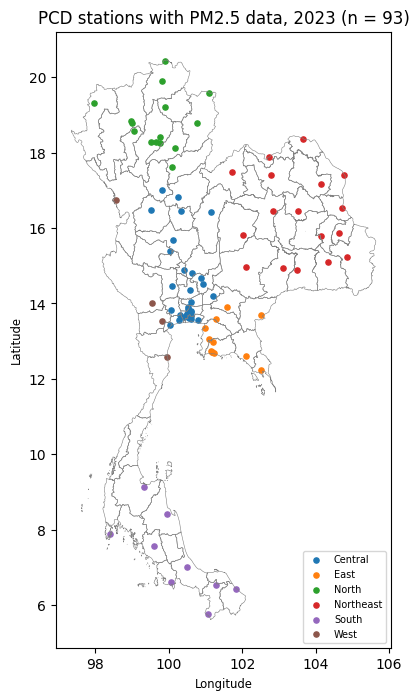

In [10]:
# ตรวจด้วยสายตา: จุดสถานีต้องอยู่ในประเทศไทย
fig, ax = plt.subplots(figsize=(5, 8))
provinces.boundary.plot(ax=ax, linewidth=0.4, color="0.5")
stations_gdf.plot(ax=ax, column="region", markersize=14, legend=True,
                  legend_kwds={"fontsize": 7, "loc": "lower right"})
ax.set_title(f"PCD stations with PM2.5 data, {YEAR} (n = {len(stations_gdf)})")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.show()

---
## ส่วน C — ดึงค่า AOD ที่ตำแหน่งสถานีจาก Google Earth Engine

### ชุดข้อมูล `MODIS/061/MCD19A2_GRANULES`

- MAIAC AOD จาก MODIS Terra + Aqua ความละเอียด 1 km
- เก็บเป็น **granule** (หนึ่งภาพต่อหนึ่งรอบโคจรต่อหนึ่ง tile) วันหนึ่งจึงมีหลายภาพ ต้องรวมเป็นภาพรายวันเอง
- ดาวเทียมผ่านประเทศไทยราว 10:30 (Terra) และ 13:30 (Aqua) ตามเวลาไทย ซึ่งเป็น 03:30 และ 06:30 UTC
  วันที่ UTC กับวันที่ไทยจึงตรงกัน กรองด้วยวันที่ UTC ได้โดยตรง

### สองขั้นตอนที่ต้องทำกับทุกภาพ

**1. ปรับค่าด้วย scale factor**

$$\mathrm{AOD}_{550} = DN \times 0.001$$

**2. เก็บเฉพาะ pixel คุณภาพดีที่สุด** จากแบนด์ `AOD_QA` บิตที่ 8–11

$$\text{best} = \big[(QA \gg 8)\ \&\ 15\big] = 0$$

อ่านว่า เลื่อนบิตไปทางขวา 8 ตำแหน่ง แล้วเก็บ 4 บิตล่าง ถ้าได้ 0 คือ "Best quality" (ไม่มีเมฆ ไม่ติดขอบเมฆ)

In [13]:
import ee

ee.Authenticate()
ee.Initialize(project=PROJECT)
print("Earth Engine พร้อมใช้งาน")

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Earth Engine พร้อมใช้งาน


In [14]:
region = ee.Geometry.Rectangle(BBOX)

collection = (
    ee.ImageCollection("MODIS/061/MCD19A2_GRANULES")
    .filterDate(str(START.date()), str(END.date()))
    .filterBounds(region)
)
print("จำนวน granule ในช่วงเวลา:", collection.size().getInfo())

จำนวน granule ในช่วงเวลา: 7605


In [15]:
BANDS = ["aod_055", "column_wv"]

def prepare(image):
    # ปรับ scale และเก็บเฉพาะ pixel ที่ QA = best quality
    qa = image.select("AOD_QA")
    best = qa.rightShift(8).bitwiseAnd(15).eq(0)

    aod = image.select("Optical_Depth_055").multiply(0.001).rename("aod_055")
    wv = image.select("Column_WV").multiply(0.001).rename("column_wv")   # หน่วย cm

    return ee.Image(
        aod.addBands(wv).updateMask(best).toFloat()
        .copyProperties(image, ["system:time_start"])
    )

# ภาพว่าง (ถูก mask ทั้งภาพ) ใช้กันกรณีวันที่ไม่มี granule เลย
EMPTY = ee.Image.constant([0, 0]).rename(BANDS).toFloat().updateMask(0)

def daily_image(date):
    # รวมทุก granule ของหนึ่งวันเป็นภาพเดียวด้วยค่าเฉลี่ย
    date = ee.Date(date)
    day = collection.filterDate(date, date.advance(1, "day")).map(prepare)
    merged = day.merge(ee.ImageCollection([EMPTY]))
    return merged.mean().set("system:time_start", date.millis())

### ดึงค่าที่สถานี

สถานีเป็น "จุด" แต่ pixel ดาวเทียมกว้าง 1 km และค่ารายจุดมี noise สูง
จึงใช้ค่าเฉลี่ยในวงกลมรัศมี 1.5 km รอบสถานี (ประมาณ 3 × 3 pixel) และเก็บ **จำนวน pixel ที่มีค่า** ไว้ด้วย
เพื่อให้นิสิตใช้กรองคุณภาพใน Notebook 02

In [16]:
station_fc = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([row.lon, row.lat]).buffer(BUFFER_M), {"station": row.station})
    for row in stations_gdf.itertuples()
])

reducer = ee.Reducer.mean().combine(ee.Reducer.count(), sharedInputs=True)

def extract_day(date_str):
    # คืนค่า list ของ dict หนึ่งรายการต่อหนึ่งสถานี
    fc = daily_image(date_str).reduceRegions(
        collection=station_fc, reducer=reducer, scale=1000,
    )
    rows = []
    for f in fc.getInfo()["features"]:
        p = f["properties"]
        rows.append({
            "date": date_str,
            "station": p["station"],
            "aod_055": p.get("aod_055_mean"),          # None = ไม่มี pixel คุณภาพดี
            "aod_n_pixels": p.get("aod_055_count", 0),
            "column_wv": p.get("column_wv_mean"),
        })
    return rows

# ทดสอบหนึ่งวันก่อนรันทั้งหมด
test = pd.DataFrame(extract_day(f"{YEAR}-03-15"))
print("สถานีที่ได้ค่า AOD ในวันทดสอบ:", test["aod_055"].notna().sum(), "จาก", len(test))
test.head()

สถานีที่ได้ค่า AOD ในวันทดสอบ: 64 จาก 93


,date,station,aod_055,aod_n_pixels,column_wv
0,2023-03-15,02T,NaN,0,NaN
1,2023-03-15,03T,NaN,0,NaN
2,2023-03-15,05T,NaN,0,NaN
3,2023-03-15,08T,NaN,0,NaN
4,2023-03-15,100T,NaN,0,NaN


In [17]:
# รันทุกวัน (89 วัน ใช้เวลาหลายนาที)
# ผลแต่ละวันถูกเก็บไว้ ถ้าหลุดกลางทางให้รัน cell นี้ซ้ำ จะทำต่อจากวันที่ค้าง
dates = pd.date_range(START, END - pd.Timedelta(days=1)).strftime("%Y-%m-%d")

if "aod_rows" not in globals():
    aod_rows = {}

for i, d in enumerate(dates, start=1):
    if d in aod_rows:
        continue
    for attempt in range(3):
        try:
            aod_rows[d] = extract_day(d)
            break
        except Exception as err:
            print(f"  {d} ลองใหม่ครั้งที่ {attempt + 1}: {err}")
            time.sleep(10)
    if i % 10 == 0:
        print(f"เสร็จ {i}/{len(dates)} วัน")

missing_days = [d for d in dates if d not in aod_rows]
print("วันที่ดึงไม่สำเร็จ:", missing_days if missing_days else "ไม่มี")

เสร็จ 10/89 วัน
เสร็จ 20/89 วัน
เสร็จ 30/89 วัน
เสร็จ 40/89 วัน
เสร็จ 50/89 วัน
เสร็จ 60/89 วัน
เสร็จ 70/89 วัน
เสร็จ 80/89 วัน
วันที่ดึงไม่สำเร็จ: ไม่มี


In [18]:
aod_daily = pd.DataFrame([row for d in dates if d in aod_rows for row in aod_rows[d]])
aod_daily["date"] = pd.to_datetime(aod_daily["date"])
aod_daily["aod_n_pixels"] = aod_daily["aod_n_pixels"].fillna(0).astype(int)

# รวมกับ PM2.5 และข้อมูลสถานี -> ตารางหลักของบทเรียน
info = pd.DataFrame(stations_gdf.drop(columns="geometry"))[
    ["station", "name_en", "lat", "lon", "prov_en", "prov_th", "region"]
]
matchup = (
    pm_long.merge(aod_daily, on=["date", "station"], how="inner")
    .merge(info, on="station", how="left")
    .sort_values(["station", "date"])
)
matchup.to_csv(DATA_DIR / "aod_pm_matchup.csv", index=False)

both = matchup[["pm25", "aod_055"]].notna().all(axis=1)
print(f"แถวทั้งหมด: {len(matchup):,}")
print(f"มี PM2.5: {matchup['pm25'].notna().mean()*100:.1f}% | มี AOD: {matchup['aod_055'].notna().mean()*100:.1f}%")
print(f"คู่ที่มีทั้งสองค่า: {both.sum():,} คู่")
print(f"Pearson r (ทุกสถานีรวมกัน): {matchup.loc[both, 'pm25'].corr(matchup.loc[both, 'aod_055']):.2f}")

แถวทั้งหมด: 8,277
มี PM2.5: 88.8% | มี AOD: 60.9%
คู่ที่มีทั้งสองค่า: 4,434 คู่
Pearson r (ทุกสถานีรวมกัน): 0.63


> 📌 **หมายเหตุผู้สอน** — สัดส่วน "มี AOD" ที่ต่ำกว่า PM2.5 มากเป็นเรื่องปกติ เพราะเมฆและควันหนาทำให้ดาวเทียมวัดไม่ได้
> นี่คือประเด็นหลักของ Notebook 02 อย่าเติมค่าที่หายไปในขั้นนี้

---
## ส่วน D — ภาพ AOD เฉลี่ยรายเดือน (GeoTIFF)

ใช้ทำแผนที่ใน Notebook 01 และใช้เป็นข้อมูลนำเข้าของแบบจำลองใน Notebook 05

แต่ละไฟล์มี 3 แบนด์
1. `aod_055` — ค่าเฉลี่ยของภาพรายวันในเดือนนั้น
2. `column_wv` — ไอน้ำในคอลัมน์เฉลี่ย (cm) ใช้เป็นตัวแปรทำนายใน Notebook 05
3. `n_days` — จำนวนวันที่ pixel นั้นมีค่า AOD คุณภาพดี

กรอบภาพครอบคลุมประเทศเพื่อนบ้านด้วยโดยตั้งใจ เพื่อให้นิสิตเห็นหมอกควันข้ามแดน

In [19]:
def monthly_image(year, month):
    start = ee.Date.fromYMD(year, month, 1)
    n_days = start.advance(1, "month").difference(start, "day")
    days = ee.List.sequence(0, n_days.subtract(1)).map(
        lambda i: daily_image(start.advance(i, "day"))
    )
    daily = ee.ImageCollection.fromImages(days)
    return (
        daily.select("aod_055").mean()
        .addBands(daily.select("column_wv").mean())
        .addBands(daily.select("aod_055").count().rename("n_days"))
        .toFloat()
    )

for month in MONTHS:
    out_path = DATA_DIR / f"aod_{YEAR}_{month:02d}.tif"
    url = monthly_image(YEAR, month).getDownloadURL({
        "region": region, "crs": "EPSG:4326", "scale": 1000, "format": "GEO_TIFF",
    })
    r = requests.get(url, timeout=900)
    r.raise_for_status()
    out_path.write_bytes(r.content)
    print(out_path, f"{out_path.stat().st_size / 1e6:.1f} MB")

data/aod_2023_02.tif 9.7 MB
data/aod_2023_03.tif 10.5 MB
data/aod_2023_04.tif 10.4 MB


ถ้า cell ข้างบนแจ้งว่าคำขอใหญ่เกินไปหรือหมดเวลา ให้ส่งออกผ่าน Google Drive แทน (ลบ `#` แล้วรัน จากนั้นย้ายไฟล์จาก Drive มาไว้ใน `data/`)

In [20]:
# for month in MONTHS:
#     ee.batch.Export.image.toDrive(
#         image=monthly_image(YEAR, month),
#         description=f"aod_{YEAR}_{month:02d}",
#         folder="AOD_PM25_teaching",
#         region=region, crs="EPSG:4326", scale=1000, maxPixels=1e9,
#     ).start()

ขนาดภาพ: 1003 x 1789 | CRS: EPSG:4326


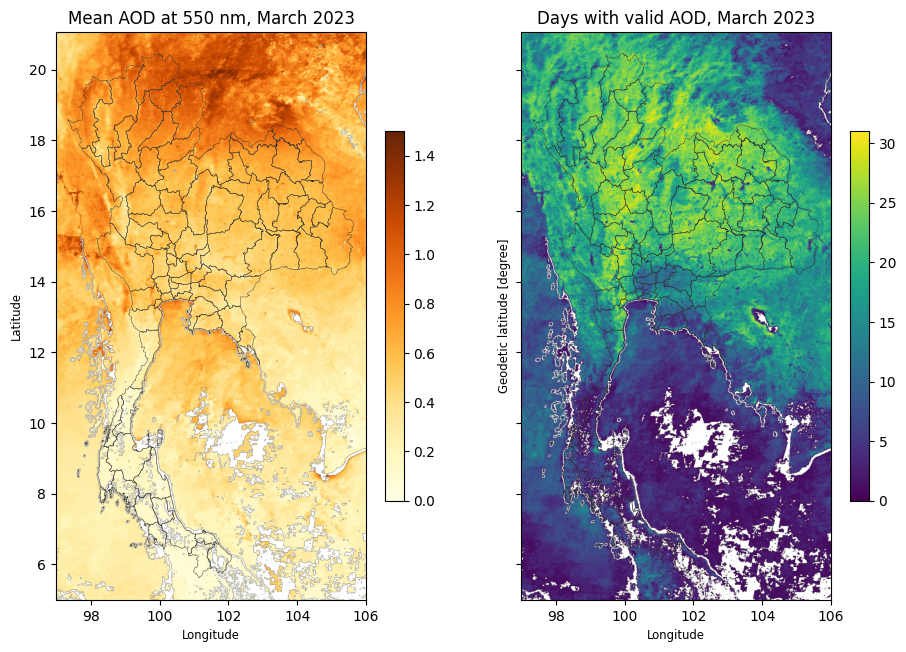

In [21]:
# ตรวจภาพที่ได้: เดือนมีนาคม
import rasterio
from rasterio.plot import plotting_extent

with rasterio.open(DATA_DIR / f"aod_{YEAR}_03.tif") as src:
    aod = src.read(1, masked=True)
    n_days = src.read(3, masked=True)
    extent = plotting_extent(src)
    print("ขนาดภาพ:", src.width, "x", src.height, "| CRS:", src.crs)

fig, axes = plt.subplots(1, 2, figsize=(11, 8), sharey=True)
for ax, data, title, cmap, vmax in [
    (axes[0], aod, "Mean AOD at 550 nm", "YlOrBr", 1.5),
    (axes[1], n_days, "Days with valid AOD", "viridis", 31),
]:
    im = ax.imshow(data, extent=extent, cmap=cmap, vmin=0, vmax=vmax)
    provinces.boundary.plot(ax=ax, linewidth=0.3, color="0.2")
    ax.set_title(f"{title}, March {YEAR}")
    ax.set_xlabel("Longitude")
    fig.colorbar(im, ax=ax, shrink=0.6)
axes[0].set_ylabel("Latitude")
plt.show()

---
## สรุปและส่งต่อ

ตรวจว่าไฟล์ครบ แล้วบีบอัดเพื่อดาวน์โหลด

In [22]:
expected = ["pm25_long.csv", "stations.geojson", "provinces.geojson", "aod_pm_matchup.csv"]
expected += [f"aod_{YEAR}_{m:02d}.tif" for m in MONTHS]

for name in expected:
    path = DATA_DIR / name
    status = f"{path.stat().st_size / 1e6:6.2f} MB" if path.exists() else "ไม่พบไฟล์"
    print(f"{name:26s} {status}")

pm25_long.csv                0.17 MB
stations.geojson             0.04 MB
provinces.geojson            1.26 MB
aod_pm_matchup.csv           1.17 MB
aod_2023_02.tif              9.74 MB
aod_2023_03.tif             10.53 MB
aod_2023_04.tif             10.36 MB


In [23]:
import shutil
from google.colab import files

shutil.make_archive("aod_pm25_data", "zip", DATA_DIR)
files.download("aod_pm25_data.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### ขั้นตอนต่อไปสำหรับผู้สอน

1. แตกไฟล์ zip แล้วอัปโหลดโฟลเดอร์ `data/` ขึ้น `nattaponm/Teach_AOD_PM_PCD` (branch `main`)
2. Notebook 01–05 จะอ่านไฟล์จาก raw URL ของ repository นั้น นิสิตไม่ต้องมีบัญชี Earth Engine

### ไฟล์ที่ได้

| ไฟล์ | เนื้อหา | ใช้ใน |
|---|---|---|
| `pm25_long.csv` | date, station, pm25 (µg/m³ รายวัน) | 01 |
| `stations.geojson` | พิกัดสถานี จังหวัด ภาค | 01–05 |
| `provinces.geojson` | ขอบเขต 77 จังหวัด พร้อมภาค | 01–05 |
| `aod_pm_matchup.csv` | PM2.5 คู่กับ AOD, จำนวน pixel, column water vapour รายสถานีรายวัน | 02–04 |
| `aod_YYYY_MM.tif` | AOD และ column water vapour เฉลี่ยรายเดือน กับจำนวนวันที่มีข้อมูล ความละเอียด 1 km | 01, 05 |

### ข้อควรจำเมื่อนำข้อมูลไปสอน

```
AOD (ทั้งคอลัมน์บรรยากาศ ไม่มีหน่วย)   ≠   PM2.5 (ที่พื้นผิว µg/m³)
AOD ขณะดาวเทียมผ่าน (~10:30, 13:30)   ≠   PM2.5 เฉลี่ย 24 ชั่วโมง
ไม่มีค่า AOD                           ≠   อากาศสะอาด
ค่าเฉลี่ยรายเดือนจากวันที่ฟ้าเปิด        ≠   ค่าเฉลี่ยของทุกวันในเดือน
```

### แหล่งข้อมูล

- Lyapustin, A., Wang, Y. MCD19A2 MODIS/Terra+Aqua Land Aerosol Optical Depth Daily L2G Global 1km SIN Grid V061. NASA LP DAAC. https://doi.org/10.5067/MODIS/MCD19A2.061
- กรมควบคุมมลพิษ (PCD) และ Air4Thai — ข้อมูล PM2.5 รายวันและพิกัดสถานี
- OpenGISData-Thailand — ขอบเขตจังหวัด https://github.com/chingchai/OpenGISData-Thailand